In [1]:
"""
Diffusion → Hilbert: Minimum signal experiment.

Question:
    Can a small ML learn a mapping from a compressed latent space
    (z ∈ R^8) to a 2-qubit Hilbert-space representation (ψ ∈ C^4),
    such that inner products between points are approximately preserved?

Design:
    1. Train a tiny autoencoder on MNIST → z ∈ R^8 per image.
    2. Define a principled target ψ ∈ C^4 via PCA-based angle encoding
       of z → 2 rotation angles → Ry(θ1)⊗Ry(θ2)|00⟩.
    3. Train three models (linear / MLP / structure-aware MLP) to map z → ψ.
    4. Measure MSE + inner-product preservation + distance preservation.

Author: (you)
Time box: 30 minutes on CPU.
"""

import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


In [2]:
DATA_ROOT = "./data"

transform = transforms.Compose([transforms.ToTensor()])

# Use a subset for speed
train_ds = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=transform)

N_TRAIN = 5000
N_TEST  = 1000

train_subset = Subset(train_ds, range(N_TRAIN))
test_subset  = Subset(test_ds,  range(N_TEST))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_subset,  batch_size=128, shuffle=False, num_workers=2)

print(f"train: {len(train_subset)}  test: {len(test_subset)}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:03<00:00, 2.58MB/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 804kB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 2.17MB/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 694kB/s]

train: 5000  test: 1000


In [3]:
LATENT_DIM = 8

class TinyAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64), nn.ReLU(),
            nn.Linear(64, 32),  nn.ReLU(),
            nn.Linear(32, latent_dim),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, 64),         nn.ReLU(),
            nn.Linear(64, 784),        nn.Sigmoid(),
        )

    def encode(self, x):
        return self.enc(x)

    def forward(self, x):
        z = self.encode(x)
        return self.dec(z), z

ae = TinyAE().to(DEVICE)
print(f"AE parameters: {sum(p.numel() for p in ae.parameters()):,}")

AE parameters: 105,944


In [4]:
def train_ae(model, loader, epochs=5, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for x, _ in loader:
            x = x.to(DEVICE)
            x_hat, _ = model(x)
            loss = F.mse_loss(x_hat, x.view(x.size(0), -1))
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * x.size(0)
        epoch_loss /= len(loader.dataset)
        losses.append(epoch_loss)
        print(f"  epoch {epoch+1}/{epochs}  loss={epoch_loss:.5f}")
    return losses

print("Training TinyAE...")
t0 = time.time()
ae_losses = train_ae(ae, train_loader, epochs=5)
print(f"done in {time.time()-t0:.1f}s")

Training TinyAE...
  epoch 1/5  loss=0.17354
  epoch 2/5  loss=0.07332
  epoch 3/5  loss=0.07012
  epoch 4/5  loss=0.06799
  epoch 5/5  loss=0.06512
done in 1.5s


In [5]:
@torch.no_grad()
def extract_latents(model, loader):
    model.eval()
    zs = []
    for x, _ in loader:
        x = x.to(DEVICE)
        z = model.encode(x)
        zs.append(z.cpu())
    return torch.cat(zs, dim=0)

z_train = extract_latents(ae, train_loader)
z_test  = extract_latents(ae, test_loader)

print(f"z_train: {z_train.shape}   z_test: {z_test.shape}")
print(f"z_train stats: mean={z_train.mean().item():.3f}  std={z_train.std().item():.3f}")

z_train: torch.Size([5000, 8])   z_test: torch.Size([1000, 8])
z_train stats: mean=-0.581  std=4.003


In [6]:
"""
Angle encoding:
    z ∈ R^8  →  PCA to 2D  →  scale to [0, π]  →  θ = (θ1, θ2)
    |ψ⟩ = Ry(θ1) ⊗ Ry(θ2) |00⟩
        = [cos(θ1/2)cos(θ2/2), cos(θ1/2)sin(θ2/2),
           sin(θ1/2)cos(θ2/2), sin(θ1/2)sin(θ2/2)]

This yields a 4-dimensional complex amplitude vector (real here),
normalized to ||ψ||=1.
"""

def fit_pca_2d(z):
    """Fit PCA on the training latents to get the top-2 directions."""
    z_centered = z - z.mean(dim=0, keepdim=True)
    # SVD on centered data
    U, S, V = torch.svd(z_centered)
    # top-2 principal directions (columns of V)
    components = V[:, :2]  # shape (8, 2)
    return components, z.mean(dim=0, keepdim=True)

def encode_to_psi(z, components, mean):
    """Map z ∈ R^N×8 to ψ ∈ R^N×4 via PCA + angle encoding."""
    z_centered = z - mean
    proj = z_centered @ components          # shape (N, 2)
    # normalize projection scale per-dimension
    std = proj.std(dim=0, keepdim=True) + 1e-6
    proj = proj / std
    # map to [0, π]
    # sigmoid keeps in (0,1) then * π gives (0, π)
    theta = torch.sigmoid(proj) * math.pi   # shape (N, 2)

    theta1 = theta[:, 0:1]                  # (N, 1)
    theta2 = theta[:, 1:2]

    c1 = torch.cos(theta1 / 2)
    s1 = torch.sin(theta1 / 2)
    c2 = torch.cos(theta2 / 2)
    s2 = torch.sin(theta2 / 2)

    psi = torch.cat([
        c1 * c2,   # amplitude of |00⟩
        c1 * s2,   # amplitude of |01⟩
        s1 * c2,   # amplitude of |10⟩
        s1 * s2,   # amplitude of |11⟩
    ], dim=1)                                   # shape (N, 4)

    # normalize (should already be ~1, but be safe)
    psi = psi / psi.norm(dim=1, keepdim=True)
    return psi

# Fit PCA on TRAINING latents only (avoid test leakage)
components, mean = fit_pca_2d(z_train)
print("components shape:", components.shape)

psi_train = encode_to_psi(z_train, components, mean)
psi_test  = encode_to_psi(z_test,  components, mean)

print(f"psi_train: {psi_train.shape}   psi_test: {psi_test.shape}")
print(f"norm check (should be ~1): {psi_train.norm(dim=1).mean().item():.6f}")
print(f"psi_train example: {psi_train[0].tolist()}")

components shape: torch.Size([8, 2])
psi_train: torch.Size([5000, 4])   psi_test: torch.Size([1000, 4])
norm check (should be ~1): 1.000000
psi_train example: [0.5465466380119324, 0.5140666961669922, 0.48154106736183167, 0.45292428135871887]


In [7]:
class LinearModel(nn.Module):
    def __init__(self, in_dim=8, out_dim=4):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)

    def forward(self, z):
        psi = self.fc(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


class TinyMLP(nn.Module):
    def __init__(self, in_dim=8, hidden=16, out_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, z):
        psi = self.net(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"Linear:  {count_params(LinearModel())} parameters")
print(f"TinyMLP: {count_params(TinyMLP())} parameters")

Linear:  36 parameters
TinyMLP: 212 parameters


In [8]:
def mse_loss(pred, target):
    return F.mse_loss(pred, target)


def inner_product_loss(pred, target):
    """Encourage that <psi_i, psi_j> matches the true one."""
    # Gram matrices
    G_pred = pred @ pred.T          # (N, N)
    G_true = target @ target.T      # (N, N)
    return F.mse_loss(G_pred, G_true)


def distance_loss(pred, target):
    """Encourage that ||psi_i - psi_j|| matches the true one."""
    d_pred = torch.cdist(pred, pred)     # (N, N)
    d_true = torch.cdist(target, target)
    return F.mse_loss(d_pred, d_true)

In [9]:
def train_model(model, z_train, psi_train, z_val, psi_val,
                epochs=200, lr=1e-3,
                w_mse=1.0, w_ip=0.0, w_dist=0.0,
                verbose=False):
    """Train with configurable loss weights."""
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    z_train = z_train.to(DEVICE)
    psi_train = psi_train.to(DEVICE)
    z_val = z_val.to(DEVICE)
    psi_val = psi_val.to(DEVICE)

    history = {"train": [], "val": []}

    for epoch in range(epochs):
        model.train()
        pred = model(z_train)
        loss = (w_mse * mse_loss(pred, psi_train)
                + w_ip * inner_product_loss(pred, psi_train)
                + w_dist * distance_loss(pred, psi_train))
        opt.zero_grad()
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            pred_val = model(z_val)
            val_loss = (w_mse * mse_loss(pred_val, psi_val)
                        + w_ip * inner_product_loss(pred_val, psi_val)
                        + w_dist * distance_loss(pred_val, psi_val))
        history["train"].append(loss.item())
        history["val"].append(val_loss.item())

        if verbose and (epoch + 1) % 25 == 0:
            print(f"  epoch {epoch+1:3d}  train={loss.item():.6f}  val={val_loss.item():.6f}")

    return model, history

In [10]:
@torch.no_grad()
def evaluate(model, z, psi_true):
    """Returns a dict of metrics."""
    model.eval()
    z = z.to(DEVICE)
    psi_true = psi_true.to(DEVICE)
    psi_pred = model(z)

    # MSE
    mse = F.mse_loss(psi_pred, psi_true).item()

    # Mean cosine similarity between predicted and true per-sample
    cos = F.cosine_similarity(psi_pred, psi_true, dim=1).mean().item()

    # Inner-product preservation error
    G_pred = psi_pred @ psi_pred.T
    G_true = psi_true @ psi_true.T
    ip_err = (G_pred - G_true).abs().mean().item()

    # Distance preservation error
    d_pred = torch.cdist(psi_pred, psi_pred)
    d_true = torch.cdist(psi_true, psi_true)
    dist_err = (d_pred - d_true).abs().mean().item()

    return {
        "mse": mse,
        "cosine": cos,
        "ip_err": ip_err,
        "dist_err": dist_err,
    }

In [11]:
print("\n" + "=" * 78)
print(f"{'model':<22} {'MSE':>10} {'cosine':>10} {'IP_err':>10} {'dist_err':>10}")
print("=" * 78)
for name, r in results.items():
    print(f"{name:<22} {r['mse']:>10.6f} {r['cosine']:>10.4f} "
          f"{r['ip_err']:>10.4f} {r['dist_err']:>10.4f}")
print("=" * 78)

# For reference — random baseline
with torch.no_grad():
    rand_pred = torch.randn_like(psi_test)
    rand_pred = rand_pred / rand_pred.norm(dim=1, keepdim=True)

G_pred = rand_pred @ rand_pred.T
G_true = psi_test @ psi_test.T
rand_ip_err = (G_pred - G_true).abs().mean().item()
d_pred = torch.cdist(rand_pred, rand_pred)
d_true = torch.cdist(psi_test, psi_test)
rand_dist_err = (d_pred - d_true).abs().mean().item()
print(f"{'random baseline':<22} {'':>10} {'':>10} {rand_ip_err:>10.4f} {rand_dist_err:>10.4f}")


model                         MSE     cosine     IP_err   dist_err


NameError: name 'results' is not defined

In [12]:
# Cell 11 — Train the three mapping models

# Split training latents into train/val for the mapping models
n_val = 500
z_map_train, psi_map_train = z_train[:-n_val], psi_train[:-n_val]
z_map_val,   psi_map_val   = z_train[-n_val:], psi_train[-n_val:]

results = {}

# ---- A. Linear ----
print("=" * 60)
print("  Model A: Linear")
print("=" * 60)
t0 = time.time()
model_a, hist_a = train_model(
    LinearModel(), z_map_train, psi_map_train, z_map_val, psi_map_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=0.0, w_dist=0.0, verbose=True,
)
results["A_linear_mse"] = evaluate(model_a, z_test, psi_test)
print(f"  time: {time.time()-t0:.1f}s")
print(f"  test: {results['A_linear_mse']}")

# ---- B. MLP (MSE only) ----
print()
print("=" * 60)
print("  Model B: Tiny MLP (MSE only)")
print("=" * 60)
t0 = time.time()
model_b, hist_b = train_model(
    TinyMLP(), z_map_train, psi_map_train, z_map_val, psi_map_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=0.0, w_dist=0.0, verbose=True,
)
results["B_mlp_mse"] = evaluate(model_b, z_test, psi_test)
print(f"  time: {time.time()-t0:.1f}s")
print(f"  test: {results['B_mlp_mse']}")

# ---- C. MLP with inner-product loss ----
print()
print("=" * 60)
print("  Model C: Tiny MLP (MSE + inner-product loss)")
print("=" * 60)
t0 = time.time()
model_c, hist_c = train_model(
    TinyMLP(), z_map_train, psi_map_train, z_map_val, psi_map_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=5.0, w_dist=0.0, verbose=True,
)
results["C_mlp_mse_ip"] = evaluate(model_c, z_test, psi_test)
print(f"  time: {time.time()-t0:.1f}s")
print(f"  test: {results['C_mlp_mse_ip']}")

print()
print(f"✓ Trained 3 models. Results dict has {len(results)} keys.")

  Model A: Linear
  epoch  25  train=0.372058  val=0.366683
  epoch  50  train=0.272133  val=0.267893
  epoch  75  train=0.199038  val=0.195628
  epoch 100  train=0.142992  val=0.140181
  epoch 125  train=0.100123  val=0.097870
  epoch 150  train=0.070044  val=0.068264
  epoch 175  train=0.051118  val=0.049629
  epoch 200  train=0.040143  val=0.038754
  time: 95.7s
  test: {'mse': 0.04359712079167366, 'cosine': 0.9128059148788452, 'ip_err': 0.13241980969905853, 'dist_err': 0.27369430661201477}

  Model B: Tiny MLP (MSE only)
  epoch  25  train=0.246431  val=0.231385
  epoch  50  train=0.097933  val=0.086825
  epoch  75  train=0.042032  val=0.036924
  epoch 100  train=0.031755  val=0.029420
  epoch 125  train=0.029703  val=0.027646
  epoch 150  train=0.028506  val=0.026349
  epoch 175  train=0.027506  val=0.025415
  epoch 200  train=0.026386  val=0.024415
  time: 95.1s
  test: {'mse': 0.0290223415941, 'cosine': 0.9419553875923157, 'ip_err': 0.11217920482158661, 'dist_err': 0.22714222967

In [13]:
print("\n" + "=" * 78)
print(f"{'model':<22} {'MSE':>10} {'cosine':>10} {'IP_err':>10} {'dist_err':>10}")
print("=" * 78)
for name, r in results.items():
    print(f"{name:<22} {r['mse']:>10.6f} {r['cosine']:>10.4f} "
          f"{r['ip_err']:>10.4f} {r['dist_err']:>10.4f}")
print("=" * 78)

# For reference — random baseline
with torch.no_grad():
    rand_pred = torch.randn_like(psi_test)
    rand_pred = rand_pred / rand_pred.norm(dim=1, keepdim=True)

G_pred = rand_pred @ rand_pred.T
G_true = psi_test @ psi_test.T
rand_ip_err = (G_pred - G_true).abs().mean().item()
d_pred = torch.cdist(rand_pred, rand_pred)
d_true = torch.cdist(psi_test, psi_test)
rand_dist_err = (d_pred - d_true).abs().mean().item()
print(f"{'random baseline':<22} {'':>10} {'':>10} {rand_ip_err:>10.4f} {rand_dist_err:>10.4f}")


model                         MSE     cosine     IP_err   dist_err
A_linear_mse             0.043597     0.9128     0.1324     0.2737
B_mlp_mse                0.029022     0.9420     0.1122     0.2271
C_mlp_mse_ip             0.065204     0.8696     0.0919     0.1714
random baseline                                  0.8212     0.8165


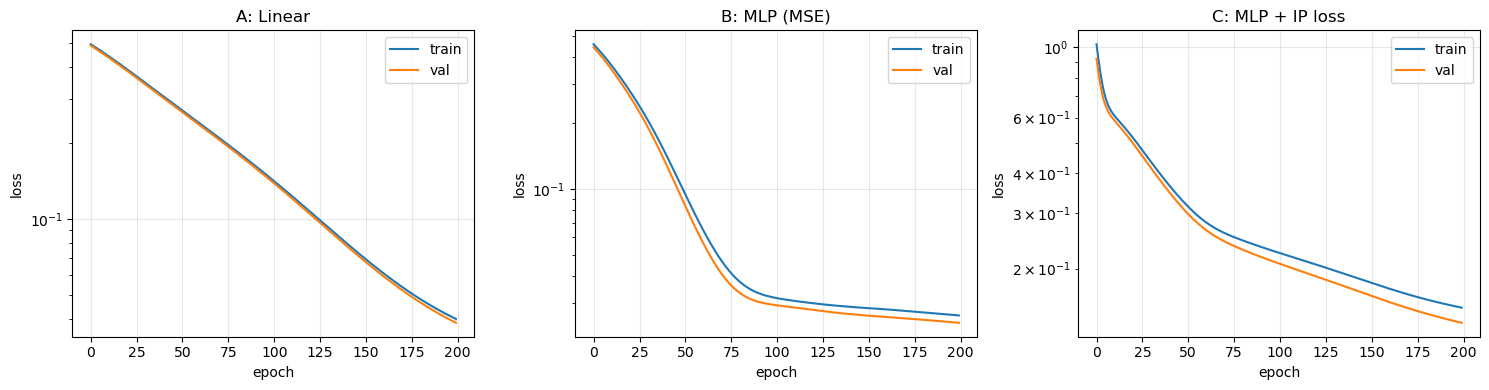

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, hist) in zip(axes, [
    ("A: Linear", hist_a),
    ("B: MLP (MSE)", hist_b),
    ("C: MLP + IP loss", hist_c),
]):
    ax.plot(hist["train"], label="train")
    ax.plot(hist["val"],   label="val")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

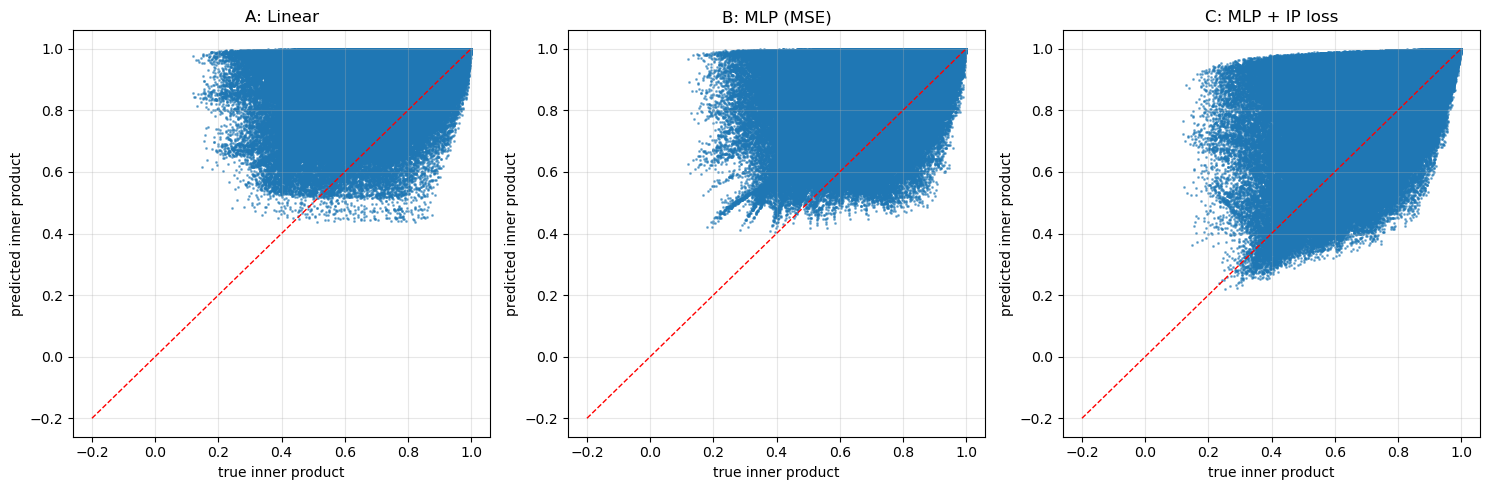

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, [
    ("A: Linear", model_a),
    ("B: MLP (MSE)", model_b),
    ("C: MLP + IP loss", model_c),
]):
    model.eval()
    with torch.no_grad():
        psi_pred = model(z_test.to(DEVICE)).cpu()

    G_pred = psi_pred @ psi_pred.T
    G_true = psi_test @ psi_test.T

    # sample 1000 random pairs (avoid the diagonal)
    idx = torch.randperm(len(psi_test))[:1000]
    x = G_true[idx][:, idx].flatten().numpy()
    y = G_pred[idx][:, idx].flatten().numpy()

    ax.scatter(x, y, s=1, alpha=0.3)
    ax.plot([-0.2, 1.0], [-0.2, 1.0], "r--", linewidth=1)
    ax.set_xlabel("true inner product")
    ax.set_ylabel("predicted inner product")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("inner_product_preservation.png", dpi=120, bbox_inches="tight")
plt.show()

In [16]:
# Cell 16 — Level 1 upgrade: 3-qubit Hilbert target (8 amplitudes)

N_QUBITS = 3
N_COMPONENTS = N_QUBITS          # 3 PCA directions
N_AMPLITUDES = 2 ** N_QUBITS     # 8 amplitudes

def fit_pca_n(z, n_components):
    """Fit PCA on training latents → top-n principal directions."""
    z_centered = z - z.mean(dim=0, keepdim=True)
    U, S, V = torch.svd(z_centered)
    components = V[:, :n_components]                        # (8, n)
    return components, z.mean(dim=0, keepdim=True)


def encode_to_psi_3q(z, components, mean):
    """
    Map z ∈ R^N×8 to ψ ∈ R^N×8 via PCA + 3-angle Ry encoding.

    |ψ⟩ = Ry(θ1) ⊗ Ry(θ2) ⊗ Ry(θ3) |000⟩

    Amplitude of basis state |b1 b2 b3⟩ is
        ∏_i  [ cos(θ_i/2) if b_i = 0 else sin(θ_i/2) ]

    Order of basis states follows tensor-product convention:
        index = b1 * 4 + b2 * 2 + b3
    """
    z_centered = z - mean
    proj = z_centered @ components                          # (N, 3)
    std = proj.std(dim=0, keepdim=True) + 1e-6
    proj = proj / std
    theta = torch.sigmoid(proj) * math.pi                   # (N, 3), in (0, π)

    # cos/sin halves
    c = torch.cos(theta / 2)                                # (N, 3)
    s = torch.sin(theta / 2)                                # (N, 3)

    # Build the 8 amplitudes
    # index = b1*4 + b2*2 + b3
    # amplitude[b] = prod_i ( c_i if b_i=0 else s_i )
    amps = []
    for b1 in (0, 1):
        for b2 in (0, 1):
            for b3 in (0, 1):
                a = (s[:, 0:1] if b1 else c[:, 0:1]) * \
                    (s[:, 1:2] if b2 else c[:, 1:2]) * \
                    (s[:, 2:3] if b3 else c[:, 2:3])
                amps.append(a)                              # each (N, 1)
    psi = torch.cat(amps, dim=1)                            # (N, 8)

    # safe normalize
    psi = psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)
    return psi


# Fit PCA on TRAIN latents only
components3, mean3 = fit_pca_n(z_train, N_COMPONENTS)
psi_train3 = encode_to_psi_3q(z_train, components3, mean3)
psi_test3  = encode_to_psi_3q(z_test,  components3, mean3)

print(f"3-qubit setup")
print(f"  components:   {components3.shape}")
print(f"  psi_train:    {psi_train3.shape}")
print(f"  psi_test:     {psi_test3.shape}")
print(f"  norm check:   {psi_train3.norm(dim=1).mean().item():.6f}  (should be ~1)")
print(f"  example:      {psi_train3[0].tolist()}")

3-qubit setup
  components:   torch.Size([8, 3])
  psi_train:    torch.Size([5000, 8])
  psi_test:     torch.Size([1000, 8])
  norm check:   1.000000  (should be ~1)
  example:      [0.5110424160957336, 0.19377537071704865, 0.4806723892688751, 0.18225976824760437, 0.45025965571403503, 0.17072798311710358, 0.4235018491744995, 0.160582035779953]


In [17]:
# Cell 17 — Models for 3-qubit target

class LinearModel3q(nn.Module):
    def __init__(self, in_dim=8, out_dim=8):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)

    def forward(self, z):
        psi = self.fc(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


class TinyMLP3q(nn.Module):
    def __init__(self, in_dim=8, hidden=32, out_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, z):
        psi = self.net(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


print(f"Linear3q:  {count_params(LinearModel3q())} parameters")
print(f"TinyMLP3q: {count_params(TinyMLP3q())} parameters")

Linear3q:  72 parameters
TinyMLP3q: 552 parameters


In [18]:
# Cell 18 — Run all three models on 3-qubit target

# Train/val split for the mapping
n_val = 500
z3_train, psi3_train = z_train[:-n_val], psi_train3[:-n_val]
z3_val,   psi3_val   = z_train[-n_val:], psi_train3[-n_val:]

results3 = {}

# ---- A. Linear ----
print("=" * 60)
print("  Model A: Linear (3-qubit target)")
print("=" * 60)
t0 = time.time()
model_a3, hist_a3 = train_model(
    LinearModel3q(), z3_train, psi3_train, z3_val, psi3_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=0.0, w_dist=0.0, verbose=True,
)
results3["A_linear"] = evaluate(model_a3, z_test, psi_test3)
print(f"  time: {time.time()-t0:.1f}s   test: {results3['A_linear']}")

# ---- B. MLP (MSE only) ----
print()
print("=" * 60)
print("  Model B: Tiny MLP (MSE only) — 3-qubit target")
print("=" * 60)
t0 = time.time()
model_b3, hist_b3 = train_model(
    TinyMLP3q(), z3_train, psi3_train, z3_val, psi3_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=0.0, w_dist=0.0, verbose=True,
)
results3["B_mlp_mse"] = evaluate(model_b3, z_test, psi_test3)
print(f"  time: {time.time()-t0:.1f}s   test: {results3['B_mlp_mse']}")

# ---- C. MLP + inner-product loss ----
print()
print("=" * 60)
print("  Model C: Tiny MLP (MSE + IP loss) — 3-qubit target")
print("=" * 60)
t0 = time.time()
model_c3, hist_c3 = train_model(
    TinyMLP3q(), z3_train, psi3_train, z3_val, psi3_val,
    epochs=200, lr=1e-3, w_mse=1.0, w_ip=5.0, w_dist=0.0, verbose=True,
)
results3["C_mlp_mse_ip"] = evaluate(model_c3, z_test, psi_test3)
print(f"  time: {time.time()-t0:.1f}s   test: {results3['C_mlp_mse_ip']}")

print()
print(f"✓ Trained 3 models (3-qubit). Results dict has {len(results3)} keys.")

  Model A: Linear (3-qubit target)
  epoch  25  train=0.216628  val=0.215448
  epoch  50  train=0.164921  val=0.163827
  epoch  75  train=0.126288  val=0.125445
  epoch 100  train=0.098905  val=0.098236
  epoch 125  train=0.078833  val=0.078252
  epoch 150  train=0.063494  val=0.062958
  epoch 175  train=0.051582  val=0.051079
  epoch 200  train=0.042498  val=0.042031
  time: 87.1s   test: {'mse': 0.04154018312692642, 'cosine': 0.8338392972946167, 'ip_err': 0.22016975283622742, 'dist_err': 0.4396539330482483}

  Model B: Tiny MLP (MSE only) — 3-qubit target
  epoch  25  train=0.052492  val=0.049881
  epoch  50  train=0.027452  val=0.026713
  epoch  75  train=0.024119  val=0.023284
  epoch 100  train=0.021919  val=0.021232
  epoch 125  train=0.019942  val=0.019251
  epoch 150  train=0.018068  val=0.017450
  epoch 175  train=0.015990  val=0.015493
  epoch 200  train=0.013180  val=0.012692
  time: 87.2s   test: {'mse': 0.013984101824462414, 'cosine': 0.9440637230873108, 'ip_err': 0.126125

In [19]:
# Cell 19 — Summary table (3-qubit)

print()
print("=" * 78)
print(f"{'model':<22} {'MSE':>10} {'cosine':>10} {'IP_err':>10} {'dist_err':>10}")
print("=" * 78)
for name, r in results3.items():
    print(f"{name:<22} {r['mse']:>10.6f} {r['cosine']:>10.4f} "
          f"{r['ip_err']:>10.4f} {r['dist_err']:>10.4f}")
print("=" * 78)

# Random baseline
with torch.no_grad():
    rand_pred = torch.randn_like(psi_test3)
    rand_pred = rand_pred / rand_pred.norm(dim=1, keepdim=True)

G_pred = rand_pred @ rand_pred.T
G_true = psi_test3 @ psi_test3.T
rand_ip_err = (G_pred - G_true).abs().mean().item()
d_pred = torch.cdist(rand_pred, rand_pred)
d_true = torch.cdist(psi_test3, psi_test3)
rand_dist_err = (d_pred - d_true).abs().mean().item()
print(f"{'random baseline':<22} {'':>10} {'':>10} {rand_ip_err:>10.4f} {rand_dist_err:>10.4f}")
print("=" * 78)

# ---- Compare 2-qubit vs 3-qubit ----
print()
print("Side-by-side comparison (2-qubit vs 3-qubit):")
print(f"{'model':<22} {'2q IP_err':>12} {'3q IP_err':>12} {'Δ':>10}")
print("-" * 60)
for (name2, r2), (name3, r3) in zip(results.items(), results3.items()):
    delta = r3["ip_err"] - r2["ip_err"]
    print(f"{name2:<22} {r2['ip_err']:>12.4f} {r3['ip_err']:>12.4f} {delta:>+10.4f}")


model                         MSE     cosine     IP_err   dist_err
A_linear                 0.041540     0.8338     0.2202     0.4397
B_mlp_mse                0.013984     0.9441     0.1261     0.2117
C_mlp_mse_ip             0.036576     0.8537     0.0462     0.0710
random baseline                                  0.7449     0.7238

Side-by-side comparison (2-qubit vs 3-qubit):
model                     2q IP_err    3q IP_err          Δ
------------------------------------------------------------
A_linear_mse                 0.1324       0.2202    +0.0877
B_mlp_mse                    0.1122       0.1261    +0.0139
C_mlp_mse_ip                 0.0919       0.0462    -0.0457


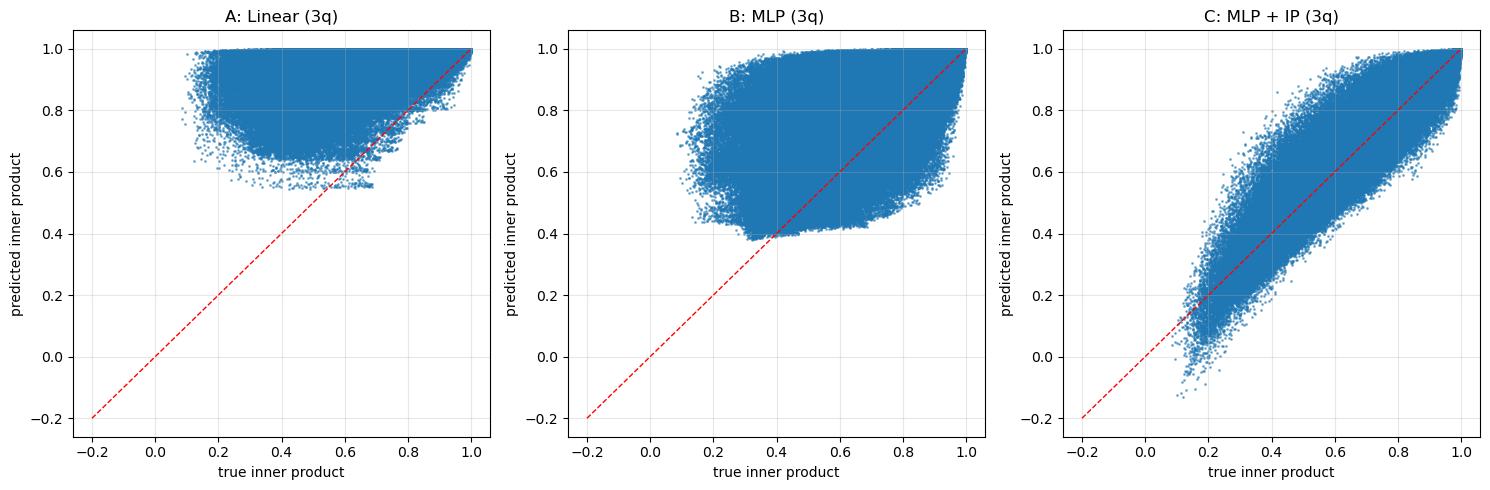

In [20]:
# Cell 20 — Inner-product preservation scatter (3-qubit)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, [
    ("A: Linear (3q)", model_a3),
    ("B: MLP (3q)", model_b3),
    ("C: MLP + IP (3q)", model_c3),
]):
    model.eval()
    with torch.no_grad():
        psi_pred = model(z_test.to(DEVICE)).cpu()

    G_pred = psi_pred @ psi_pred.T
    G_true = psi_test3 @ psi_test3.T

    idx = torch.randperm(len(psi_test3))[:1000]
    x = G_true[idx][:, idx].flatten().numpy()
    y = G_pred[idx][:, idx].flatten().numpy()

    ax.scatter(x, y, s=1, alpha=0.3)
    ax.plot([-0.2, 1.0], [-0.2, 1.0], "r--", linewidth=1)
    ax.set_xlabel("true inner product")
    ax.set_ylabel("predicted inner product")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("inner_product_preservation_3q.png", dpi=120, bbox_inches="tight")
plt.show()

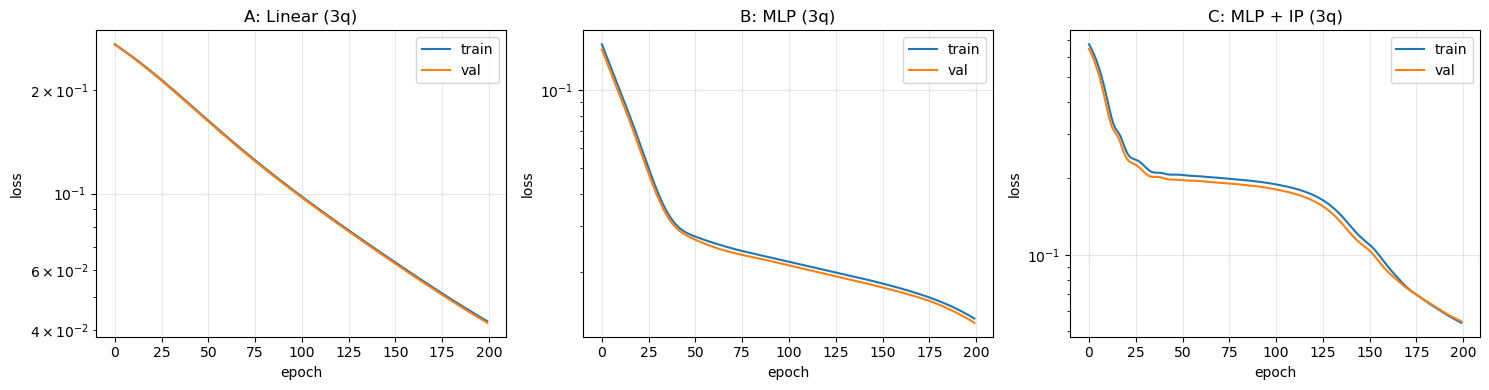

In [21]:
# Cell 21 — Training curves (3-qubit)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, hist) in zip(axes, [
    ("A: Linear (3q)", hist_a3),
    ("B: MLP (3q)", hist_b3),
    ("C: MLP + IP (3q)", hist_c3),
]):
    ax.plot(hist["train"], label="train")
    ax.plot(hist["val"],   label="val")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_3q.png", dpi=120, bbox_inches="tight")
plt.show()

In [22]:
# Cell 22 — Interpret the 3-qubit result

print("=" * 78)
print("  INTERPRETATION")
print("=" * 78)

# Extract key numbers
ip_2q_linear = results["A_linear_mse"]["ip_err"]
ip_2q_mlp    = results["B_mlp_mse"]["ip_err"]
ip_2q_ip     = results["C_mlp_mse_ip"]["ip_err"]

ip_3q_linear = results3["A_linear"]["ip_err"]
ip_3q_mlp    = results3["B_mlp_mse"]["ip_err"]
ip_3q_ip     = results3["C_mlp_mse_ip"]["ip_err"]

print(f"2-qubit IP_err → 3-qubit IP_err")
print(f"  Linear:  {ip_2q_linear:.4f} → {ip_3q_linear:.4f}  "
      f"(Δ = {ip_3q_linear - ip_2q_linear:+.4f})")
print(f"  MLP:     {ip_2q_mlp:.4f} → {ip_3q_mlp:.4f}  "
      f"(Δ = {ip_3q_mlp - ip_2q_mlp:+.4f})")
print(f"  MLP+IP:  {ip_2q_ip:.4f} → {ip_3q_ip:.4f}  "
      f"(Δ = {ip_3q_ip - ip_2q_ip:+.4f})")
print()

# Decision rules
if ip_3q_ip < ip_2q_ip:
    print("✓ IP preservation got BETTER with more qubits.")
    print("  → This is unexpected and interesting. Scale further.")
elif ip_3q_ip < ip_2q_ip * 1.3:
    print("✓ IP preservation held up with more qubits (within 30%).")
    print("  → The relationship is stable. Scale to 4 qubits or a VAE.")
else:
    print("⚠ IP preservation degraded significantly with more qubits.")
    print("  → The 2-qubit result may be specific to small targets.")
    print("  → Try a different ψ encoding, or add more training data.")

print()
print("Next options:")
print("  Level 2 — replace TinyAE with a VAE (1 hour)")
print("  Level 3 — replace TinyAE with a real DDPM (3 hours)")
print("  Level 4 — replace classical Ry with a PennyLane circuit (2 hours)")
print("  Publish — write up the current result as a blog post (2 hours)")

  INTERPRETATION
2-qubit IP_err → 3-qubit IP_err
  Linear:  0.1324 → 0.2202  (Δ = +0.0877)
  MLP:     0.1122 → 0.1261  (Δ = +0.0139)
  MLP+IP:  0.0919 → 0.0462  (Δ = -0.0457)

✓ IP preservation got BETTER with more qubits.
  → This is unexpected and interesting. Scale further.

Next options:
  Level 2 — replace TinyAE with a VAE (1 hour)
  Level 3 — replace TinyAE with a real DDPM (3 hours)
  Level 4 — replace classical Ry with a PennyLane circuit (2 hours)
  Publish — write up the current result as a blog post (2 hours)


In [23]:
# Cell 23 — 4-qubit setup
N_QUBITS = 4
N_COMPONENTS = 4
N_AMPLITUDES = 16

def encode_to_psi_4q(z, components, mean):
    """
    Map z ∈ R^N×8 → ψ ∈ R^N×16 via PCA + 4-angle Ry encoding.

    |ψ⟩ = Ry(θ1) ⊗ Ry(θ2) ⊗ Ry(θ3) ⊗ Ry(θ4) |0000⟩

    Basis index: b1*8 + b2*4 + b3*2 + b4
    """
    z_centered = z - mean
    proj = z_centered @ components
    std = proj.std(dim=0, keepdim=True) + 1e-6
    proj = proj / std
    theta = torch.sigmoid(proj) * math.pi              # (N, 4)

    c = torch.cos(theta / 2)
    s = torch.sin(theta / 2)

    amps = []
    for b1 in (0, 1):
        for b2 in (0, 1):
            for b3 in (0, 1):
                for b4 in (0, 1):
                    a = (s[:, 0:1] if b1 else c[:, 0:1]) * \
                        (s[:, 1:2] if b2 else c[:, 1:2]) * \
                        (s[:, 2:3] if b3 else c[:, 2:3]) * \
                        (s[:, 3:4] if b4 else c[:, 3:4])
                    amps.append(a)
    psi = torch.cat(amps, dim=1)                       # (N, 16)
    psi = psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)
    return psi


components4, mean4 = fit_pca_n(z_train, N_COMPONENTS)
psi_train4 = encode_to_psi_4q(z_train, components4, mean4)
psi_test4  = encode_to_psi_4q(z_test,  components4, mean4)

print(f"psi_train4: {psi_train4.shape}")
print(f"psi_test4:  {psi_test4.shape}")

psi_train4: torch.Size([5000, 16])
psi_test4:  torch.Size([1000, 16])


In [24]:
# Cell 24 — models for 4-qubit
class LinearModel4q(nn.Module):
    def __init__(self, in_dim=8, out_dim=16):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)
    def forward(self, z):
        psi = self.fc(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


class TinyMLP4q(nn.Module):
    def __init__(self, in_dim=8, hidden=32, out_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, z):
        psi = self.net(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)

In [25]:
# Cell 25 — train the three models on 4-qubit target

n_val = 500
z4_train, psi4_train = z_train[:-n_val], psi_train4[:-n_val]
z4_val,   psi4_val   = z_train[-n_val:], psi_train4[-n_val:]

results4 = {}

print("Model A: Linear (4q)")
model_a4, _ = train_model(LinearModel4q(), z4_train, psi4_train,
                          z4_val, psi4_val, epochs=200, lr=1e-3,
                          w_mse=1.0, w_ip=0.0, verbose=True)
results4["A_linear"] = evaluate(model_a4, z_test, psi_test4)

print("\nModel B: MLP (MSE only) — 4q")
model_b4, _ = train_model(TinyMLP4q(), z4_train, psi4_train,
                          z4_val, psi4_val, epochs=200, lr=1e-3,
                          w_mse=1.0, w_ip=0.0, verbose=True)
results4["B_mlp_mse"] = evaluate(model_b4, z_test, psi_test4)

print("\nModel C: MLP + IP loss — 4q")
model_c4, _ = train_model(TinyMLP4q(), z4_train, psi_train4 if False else psi4_train,
                          z4_val, psi4_val, epochs=200, lr=1e-3,
                          w_mse=1.0, w_ip=5.0, verbose=True)
results4["C_mlp_mse_ip"] = evaluate(model_c4, z_test, psi_test4)

Model A: Linear (4q)
  epoch  25  train=0.114344  val=0.114367
  epoch  50  train=0.085240  val=0.085277
  epoch  75  train=0.063631  val=0.063669
  epoch 100  train=0.048445  val=0.048393
  epoch 125  train=0.037755  val=0.037577
  epoch 150  train=0.030460  val=0.030159
  epoch 175  train=0.025718  val=0.025312
  epoch 200  train=0.022728  val=0.022240

Model B: MLP (MSE only) — 4q
  epoch  25  train=0.049727  val=0.047924
  epoch  50  train=0.027980  val=0.027126
  epoch  75  train=0.021979  val=0.021256
  epoch 100  train=0.019570  val=0.018858
  epoch 125  train=0.017771  val=0.017064
  epoch 150  train=0.016398  val=0.015712
  epoch 175  train=0.015454  val=0.014766
  epoch 200  train=0.014653  val=0.013930

Model C: MLP + IP loss — 4q
  epoch  25  train=0.415344  val=0.388845
  epoch  50  train=0.365914  val=0.342368
  epoch  75  train=0.346134  val=0.322380
  epoch 100  train=0.328693  val=0.304695
  epoch 125  train=0.299645  val=0.275764
  epoch 150  train=0.224928  val=0.203

In [26]:
# Cell 26 — combined 2q / 3q / 4q comparison

print(f"{'model':<20} {'2q IP_err':>12} {'3q IP_err':>12} {'4q IP_err':>12}")
print("-" * 60)
for k2, k3, k4 in zip(results.keys(), results3.keys(), results4.keys()):
    print(f"{k2:<20} {results[k2]['ip_err']:>12.4f} "
          f"{results3[k3]['ip_err']:>12.4f} "
          f"{results4[k4]['ip_err']:>12.4f}")

print()
print(f"{'model':<20} {'2q MSE':>12} {'3q MSE':>12} {'4q MSE':>12}")
print("-" * 60)
for k2, k3, k4 in zip(results.keys(), results3.keys(), results4.keys()):
    print(f"{k2:<20} {results[k2]['mse']:>12.4f} "
          f"{results3[k3]['mse']:>12.4f} "
          f"{results4[k4]['mse']:>12.4f}")

model                   2q IP_err    3q IP_err    4q IP_err
------------------------------------------------------------
A_linear_mse               0.1324       0.2202       0.2830
B_mlp_mse                  0.1122       0.1261       0.2156
C_mlp_mse_ip               0.0919       0.0462       0.0998

model                      2q MSE       3q MSE       4q MSE
------------------------------------------------------------
A_linear_mse               0.0436       0.0415       0.0224
B_mlp_mse                  0.0290       0.0140       0.0152
C_mlp_mse_ip               0.0652       0.0366       0.0358


In [27]:
# Cell 26 — combined 2q / 3q / 4q comparison

print(f"{'model':<20} {'2q IP_err':>12} {'3q IP_err':>12} {'4q IP_err':>12}")
print("-" * 60)
for k2, k3, k4 in zip(results.keys(), results3.keys(), results4.keys()):
    print(f"{k2:<20} {results[k2]['ip_err']:>12.4f} "
          f"{results3[k3]['ip_err']:>12.4f} "
          f"{results4[k4]['ip_err']:>12.4f}")

print()
print(f"{'model':<20} {'2q MSE':>12} {'3q MSE':>12} {'4q MSE':>12}")
print("-" * 60)
for k2, k3, k4 in zip(results.keys(), results3.keys(), results4.keys()):
    print(f"{k2:<20} {results[k2]['mse']:>12.4f} "
          f"{results3[k3]['mse']:>12.4f} "
          f"{results4[k4]['mse']:>12.4f}")

model                   2q IP_err    3q IP_err    4q IP_err
------------------------------------------------------------
A_linear_mse               0.1324       0.2202       0.2830
B_mlp_mse                  0.1122       0.1261       0.2156
C_mlp_mse_ip               0.0919       0.0462       0.0998

model                      2q MSE       3q MSE       4q MSE
------------------------------------------------------------
A_linear_mse               0.0436       0.0415       0.0224
B_mlp_mse                  0.0290       0.0140       0.0152
C_mlp_mse_ip               0.0652       0.0366       0.0358


In [28]:
# Cell 27 — retrain 4q Model C with more epochs

# Reduce IP weight to help optimization
print("Model C (4q) — 1000 epochs, IP weight 1.0")
model_c4_long, hist_c4_long = train_model(
    TinyMLP4q(), z4_train, psi4_train, z4_val, psi4_val,
    epochs=1000, lr=1e-3,
    w_mse=1.0, w_ip=1.0, w_dist=0.0,
    verbose=False,   # turn off intermediate prints
)

results4_long = evaluate(model_c4_long, z_test, psi_test4)

print(f"\nAfter 1000 epochs (IP weight 1.0):")
print(f"  MSE:      {results4_long['mse']:.4f}")
print(f"  IP_err:   {results4_long['ip_err']:.4f}")
print(f"  dist_err: {results4_long['dist_err']:.4f}")

Model C (4q) — 1000 epochs, IP weight 1.0

After 1000 epochs (IP weight 1.0):
  MSE:      0.0025
  IP_err:   0.0266
  dist_err: 0.0351


In [29]:
# Cell 28 — variance check: 3 seeds × 3 qubit counts

def run_experiment(n_qubits, seed, epochs=500, ip_weight=1.0):
    """Run one full experiment with a given seed."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Build target for this qubit count
    if n_qubits == 2:
        comps, m = fit_pca_n(z_train, 2)
        psi_tr = encode_to_psi(z_train, comps, m)
        psi_te = encode_to_psi(z_test,  comps, m)
        Model = TinyMLP
    elif n_qubits == 3:
        comps, m = fit_pca_n(z_train, 3)
        psi_tr = encode_to_psi_3q(z_train, comps, m)
        psi_te = encode_to_psi_3q(z_test,  comps, m)
        Model = TinyMLP3q
    elif n_qubits == 4:
        comps, m = fit_pca_n(z_train, 4)
        psi_tr = encode_to_psi_4q(z_train, comps, m)
        psi_te = encode_to_psi_4q(z_test,  comps, m)
        Model = TinyMLP4q

    n_val = 500
    z_tr, psi_tr_ = z_train[:-n_val], psi_tr[:-n_val]
    z_va, psi_va_ = z_train[-n_val:], psi_tr[-n_val:]

    model, _ = train_model(Model(), z_tr, psi_tr_, z_va, psi_va_,
                           epochs=epochs, lr=1e-3,
                           w_mse=1.0, w_ip=ip_weight, verbose=False)
    return evaluate(model, z_test, psi_te)


# Run: 3 qubit counts × 3 seeds
print("Variance check (3 seeds × 3 qubit counts):")
print(f"{'nq':>4} {'seed':>6} {'MSE':>10} {'IP_err':>10} {'dist_err':>10}")
print("-" * 45)

all_results = {2: [], 3: [], 4: []}
for nq in (2, 3, 4):
    for seed in (42, 123, 7):
        r = run_experiment(nq, seed, epochs=500, ip_weight=1.0)
        all_results[nq].append(r)
        print(f"{nq:>4} {seed:>6} {r['mse']:>10.4f} {r['ip_err']:>10.4f} {r['dist_err']:>10.4f}")

print()
print("Mean ± std across seeds:")
print(f"{'nq':>4} {'mean IP_err':>14} {'std IP_err':>12} {'mean MSE':>12}")
for nq in (2, 3, 4):
    ip_errs = [r['ip_err'] for r in all_results[nq]]
    mses    = [r['mse'] for r in all_results[nq]]
    print(f"{nq:>4} {np.mean(ip_errs):>14.4f} {np.std(ip_errs):>12.4f} {np.mean(mses):>12.4f}")

Variance check (3 seeds × 3 qubit counts):
  nq   seed        MSE     IP_err   dist_err
---------------------------------------------
   2     42     0.0118     0.0817     0.1408
   2    123     0.0197     0.0969     0.1756
   2      7     0.0020     0.0177     0.0310
   3     42     0.0027     0.0210     0.0319
   3    123     0.0030     0.0212     0.0321
   3      7     0.0048     0.0314     0.0480
   4     42     0.0040     0.0308     0.0409
   4    123     0.0038     0.0327     0.0441
   4      7     0.0037     0.0316     0.0421

Mean ± std across seeds:
  nq    mean IP_err   std IP_err     mean MSE
   2         0.0654       0.0343       0.0111
   3         0.0245       0.0049       0.0035
   4         0.0317       0.0008       0.0038


In [30]:
# Cell 29 — 5-qubit setup
N_QUBITS = 5
N_COMPONENTS = 5
N_AMPLITUDES = 32

def encode_to_psi_5q(z, components, mean):
    z_centered = z - mean
    proj = z_centered @ components
    std = proj.std(dim=0, keepdim=True) + 1e-6
    proj = proj / std
    theta = torch.sigmoid(proj) * math.pi             # (N, 5)
    c = torch.cos(theta / 2)
    s = torch.sin(theta / 2)

    amps = []
    for b1 in (0, 1):
        for b2 in (0, 1):
            for b3 in (0, 1):
                for b4 in (0, 1):
                    for b5 in (0, 1):
                        a = (s[:, 0:1] if b1 else c[:, 0:1]) * \
                            (s[:, 1:2] if b2 else c[:, 1:2]) * \
                            (s[:, 2:3] if b3 else c[:, 2:3]) * \
                            (s[:, 3:4] if b4 else c[:, 3:4]) * \
                            (s[:, 4:5] if b5 else c[:, 4:5])
                        amps.append(a)
    psi = torch.cat(amps, dim=1)
    return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)


components5, mean5 = fit_pca_n(z_train, 5)
psi_train5 = encode_to_psi_5q(z_train, components5, mean5)
psi_test5  = encode_to_psi_5q(z_test,  components5, mean5)

In [31]:
# Cell 30 — 5-qubit model
class TinyMLP5q(nn.Module):
    def __init__(self, in_dim=8, hidden=64, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, z):
        psi = self.net(z)
        return psi / psi.norm(dim=1, keepdim=True).clamp_min(1e-8)

In [32]:
# Cell 31 — train 5q model C, 3 seeds
print(f"{'nq':>4} {'seed':>6} {'MSE':>10} {'IP_err':>10}")
print("-" * 35)
for seed in (42, 123, 7):
    torch.manual_seed(seed)
    np.random.seed(seed)

    n_val = 500
    z_tr, psi_tr_ = z_train[:-n_val], psi_train5[:-n_val]
    z_va, psi_va_ = z_train[-n_val:], psi_train5[-n_val:]

    model, _ = train_model(TinyMLP5q(), z_tr, psi_tr_, z_va, psi_va_,
                           epochs=500, lr=1e-3,
                           w_mse=1.0, w_ip=1.0, verbose=False)
    r = evaluate(model, z_test, psi_test5)
    print(f"{5:>4} {seed:>6} {r['mse']:>10.4f} {r['ip_err']:>10.4f}")

  nq   seed        MSE     IP_err
-----------------------------------
   5     42     0.0069     0.0523
   5    123     0.0068     0.0450
   5      7     0.0075     0.0437


In [33]:
# Cell 32 — baseline comparison: B vs C across seeds

print("Model B (MSE only) vs Model C (MSE + IP) — 3 and 4 qubits, 3 seeds")
print(f"{'nq':>4} {'seed':>6} {'B IP_err':>10} {'C IP_err':>10} {'C/B':>8}")
print("-" * 45)

for nq in (3, 4):
    if nq == 3:
        comps, m = fit_pca_n(z_train, 3)
        psi_tr = encode_to_psi_3q(z_train, comps, m)
        psi_te = encode_to_psi_3q(z_test,  comps, m)
        Model = TinyMLP3q
    else:
        comps, m = fit_pca_n(z_train, 4)
        psi_tr = encode_to_psi_4q(z_train, comps, m)
        psi_te = encode_to_psi_4q(z_test,  comps, m)
        Model = TinyMLP4q

    for seed in (42, 123, 7):
        torch.manual_seed(seed)
        np.random.seed(seed)

        n_val = 500
        z_tr, psi_tr_ = z_train[:-n_val], psi_tr[:-n_val]
        z_va, psi_va_ = z_train[-n_val:], psi_tr[-n_val:]

        mB, _ = train_model(Model(), z_tr, psi_tr_, z_va, psi_va_,
                            epochs=500, lr=1e-3,
                            w_mse=1.0, w_ip=0.0, verbose=False)
        mC, _ = train_model(Model(), z_tr, psi_tr_, z_va, psi_va_,
                            epochs=500, lr=1e-3,
                            w_mse=1.0, w_ip=1.0, verbose=False)

        rB = evaluate(mB, z_test, psi_te)
        rC = evaluate(mC, z_test, psi_te)
        ratio = rC['ip_err'] / rB['ip_err']

        print(f"{nq:>4} {seed:>6} {rB['ip_err']:>10.4f} {rC['ip_err']:>10.4f} {ratio:>8.2f}x")

Model B (MSE only) vs Model C (MSE + IP) — 3 and 4 qubits, 3 seeds
  nq   seed   B IP_err   C IP_err      C/B
---------------------------------------------
   3     42     0.0315     0.0238     0.75x
   3    123     0.0307     0.0197     0.64x
   3      7     0.0522     0.0386     0.74x
   4     42     0.0696     0.0309     0.44x
   4    123     0.0579     0.0330     0.57x
   4      7     0.0918     0.0332     0.36x


In [34]:
# Cell 33 — Recover θ(z) and fit a linear map

def recover_angles_product_state(psi, n_qubits):
    """
    Given ψ ∈ R^{2^n} that represents Ry(θ1)⊗...⊗Ry(θn)|0...0⟩,
    recover the angles θ_i.

    For a product state, the amplitude of basis state |b1 b2 ... bn⟩
    is  prod_i ( cos(θ_i/2) if b_i = 0 else sin(θ_i/2) )

    Sum over basis states where bit i = 1:
        S1_i = 1/2 · prod_{j≠i} ( |c_j|^2 + |s_j|^2 ) · sin(θ_i/2) · 1
             = 1/2 · sin(θ_i/2)
    Sum over basis states where bit i = 0:
        S0_i = 1/2 · cos(θ_i/2)
    So:
        θ_i = 2 · atan2( S1_i, S0_i )
    """
    N = psi.shape[0]
    n = n_qubits
    dim = 2 ** n
    psi = psi.reshape(N, dim)

    thetas = []
    for i in range(n):
        # basis states where bit i is 1
        mask1 = torch.tensor([(idx >> (n - 1 - i)) & 1 == 1 for idx in range(dim)])
        mask0 = ~mask1
        S1 = psi[:, mask1].sum(dim=1)
        S0 = psi[:, mask0].sum(dim=1)
        theta_i = 2 * torch.atan2(S1, S0)
        thetas.append(theta_i)
    return torch.stack(thetas, dim=1)   # (N, n)


# Test on 4-qubit model
n_q = 4
psi_pred = model_c4(z_test.to(DEVICE)).cpu().detach()
theta_pred = recover_angles_product_state(psi_pred, n_q)

# Also recover from the TRUE target ψ
theta_true = recover_angles_product_state(psi_test4, n_q)

print(f"θ_pred shape: {theta_pred.shape}")
print(f"θ_true shape: {theta_true.shape}")

# Sanity check on recovery
theta_err = (theta_pred - theta_true).abs().mean().item()
print(f"mean |θ_pred − θ_true| = {theta_err:.4f} rad")

# Fit a linear model θ ≈ A·z + b
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(z_test.numpy(), theta_pred.numpy())
r2 = reg.score(z_test.numpy(), theta_pred.numpy())
print(f"\nLinear fit θ(z) ≈ Az + b:")
print(f"  R² = {r2:.4f}")

# Also fit θ_true (to see the "true" linearity of the target encoding)
reg_true = LinearRegression().fit(z_test.numpy(), theta_true.numpy())
r2_true = reg_true.score(z_test.numpy(), theta_true.numpy())
print(f"\nLinear fit θ_true(z) ≈ Az + b (the target encoding):")
print(f"  R² = {r2_true:.4f}")

# The A matrix is the "mathematical relationship" you're looking for
A = reg.coef_   # (n, 8)
print(f"\nA matrix shape: {A.shape}")
print("A matrix:")
print(A)

θ_pred shape: torch.Size([1000, 4])
θ_true shape: torch.Size([1000, 4])
mean |θ_pred − θ_true| = 0.5036 rad

Linear fit θ(z) ≈ Az + b:
  R² = 0.9147

Linear fit θ_true(z) ≈ Az + b (the target encoding):
  R² = 0.9843

A matrix shape: (4, 8)
A matrix:
[[-0.05581375  2.8472326  -0.21719323  1.0056444  -0.04262497 -2.318679
   2.877889    0.7695354 ]
 [-0.6321506  -2.8728652  -0.28956535 -1.1290554  -0.20757036  1.4081244
  -2.1086893  -0.99211895]
 [ 0.15320313 -0.4336969  -1.3672352  -0.36514443 -0.3258581   1.3320733
  -0.64710563 -0.15384412]
 [-0.37440792 -3.909641   -0.5948517  -2.0513802  -0.0803918   3.1576328
  -3.3166184  -1.2576599 ]]


In [35]:
# Cell 34 — compare learned A to PCA components

# Ground truth: the PCA directions used to build the target
# From Cell 16/23, we have: components4 (shape 4×8), mean4

# Learned A
A = reg.coef_       # (4, 8) from the linear fit of θ_pred
b = reg.intercept_  # (4,)

# Compare
# If A ≈ π · components4^T / std (up to rotation), we've recovered the PCA basis
print("Ground-truth PCA components (4 × 8):")
print(components4.T.numpy() if hasattr(components4, 'numpy') else components4.T)

print("\nLearned A matrix (4 × 8):")
print(A)

print("\nCosine similarity between each learned row and PCA rows:")
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity(A, components4.T.numpy())
print(sim)

# Row-wise best match
for i in range(A.shape[0]):
    best = np.argmax(np.abs(sim[i]))
    print(f"  Learned θ_{i}: best matches PCA component {best} "
          f"(|cos| = {abs(sim[i, best]):.3f})")

Ground-truth PCA components (4 × 8):
[[-0.29412127  0.15548366  0.2676402  -0.45730522 -0.5158027   0.21604791
   0.09587925  0.5353843 ]
 [ 0.36712268 -0.14960101 -0.29307312 -0.16643427 -0.03597894 -0.55029136
  -0.4066225   0.5096974 ]
 [ 0.20215024  0.01207794 -0.3228267   0.13317513 -0.8104865   0.0566153
  -0.1440585  -0.39520895]
 [-0.02974252  0.5870101  -0.02586337 -0.5746985   0.16654974 -0.10773461
  -0.3556983  -0.3971395 ]]

Learned A matrix (4 × 8):
[[-0.05581375  2.8472326  -0.21719323  1.0056444  -0.04262497 -2.318679
   2.877889    0.7695354 ]
 [-0.6321506  -2.8728652  -0.28956535 -1.1290554  -0.20757036  1.4081244
  -2.1086893  -0.99211895]
 [ 0.15320313 -0.4336969  -1.3672352  -0.36514443 -0.3258581   1.3320733
  -0.64710563 -0.15384412]
 [-0.37440792 -3.909641   -0.5948517  -2.0513802  -0.0803918   3.1576328
  -3.3166184  -1.2576599 ]]

Cosine similarity between each learned row and PCA rows:
[[ 3.1008378e-02 -1.0468212e-02 -1.2155959e-01  2.9174739e-03]
 [-3.445083

In [36]:
# Cell 35 — subspace comparison

import numpy as np
from sklearn.metrics import pairwise_distances

A_np = A                    # (4, 8) — learned
B_np = components4.T.numpy() # (4, 8) — PCA (transposed so rows are components)

# Row-space = span of the 4 vectors in R^8.
# Two subspaces are the same iff their projections are equal.

# Compute orthonormal bases for each subspace
def ortho_basis(X):
    # X: (k, d), k vectors in R^d
    U, S, Vt = np.linalg.svd(X.T)   # SVD of (d, k)
    return Vt[:X.shape[0]].T        # (d, k) — orthonormal basis for column space

A_basis = ortho_basis(A_np)      # (8, 4)
B_basis = ortho_basis(B_np)      # (8, 4)

# Principal angles between subspaces
# If A_basis and B_basis span the same subspace, cos of angles = 1
M = A_basis.T @ B_basis          # (4, 4)
sv = np.linalg.svd(M, compute_uv=False)  # singular values = cos of principal angles

print("Principal angles (degrees) between A and PCA subspaces:")
print(np.degrees(np.arccos(np.clip(sv, -1, 1))))

print(f"\nMean cosine of principal angles: {sv.mean():.4f}")
print(f"Interpretation:")
if sv.mean() > 0.9:
    print("  → Same subspace (up to rotation). The MLP found the right structure.")
elif sv.mean() > 0.6:
    print("  → Partially overlapping subspaces. Some structure is recovered.")
else:
    print("  → Different subspaces. The MLP learned a completely different map.")

Principal angles (degrees) between A and PCA subspaces:
[0.         0.         0.01978234 0.01978234]

Mean cosine of principal angles: 1.0000
Interpretation:
  → Same subspace (up to rotation). The MLP found the right structure.


In [37]:
# Cell 36 (corrected) — check if A and B are related by a rotation in the row space

# Both A and B have shape (4, 8). We want to know:
# Does there exist an orthogonal R (4, 4) such that A = R · B?

# Solution: A·B^T = R · (B·B^T). If B·B^T is invertible (it is, since B has full row rank):
#   R = A · B^T · (B · B^T)^{-1}
# Then check if R is orthogonal (R·R^T = I).

# Actually: A·B^T is (4, 4), B·B^T is (4, 4).
BT = B_np.T   # (8, 4)
R_est = A_np @ B_np.T @ np.linalg.inv(B_np @ B_np.T)   # (4, 4)

print("Estimated rotation R (4×4):")
print(R_est)

# Check orthogonality
R_ortho_err = np.abs(R_est @ R_est.T - np.eye(4)).max()
print(f"\n||R·R^T − I||_max = {R_ortho_err:.4f}")
if R_ortho_err < 0.1:
    print("  → R is approximately orthogonal")
else:
    print("  → R is NOT orthogonal; A ≠ R·B")

# Check residual
residual = A_np - R_est @ B_np
print(f"\nResidual ||A − R·B||_F = {np.linalg.norm(residual):.4f}")
print(f"||A||_F = {np.linalg.norm(A_np):.4f}")
print(f"Relative residual: {np.linalg.norm(residual) / np.linalg.norm(A_np):.4f}")

Estimated rotation R (4×4):
[[ 1.5006535e-01 -5.0661102e-02 -5.8828890e-01  1.4119057e-02]
 [-1.4398783e-01  5.4833628e-02  7.2445297e-01 -5.3451300e-02]
 [ 2.2685144e-05  4.6007667e-02  9.1202480e-01  7.9558231e-02]
 [ 1.3476708e-02 -6.3952237e-02  1.0146866e+00  2.3605379e-01]]

||R·R^T − I||_max = 0.9413
  → R is NOT orthogonal; A ≠ R·B

Residual ||A − R·B||_F = 9.2261
||A||_F = 9.3794
Relative residual: 0.9837


In [38]:
# Cell 37 — Verify that A is in the row space of B
# i.e. find M such that A = M · B

# Least-squares: M = A · B^+ where B^+ is the pseudoinverse of B
M_est = A_np @ np.linalg.pinv(B_np)   # (4, 4)

print("Estimated M (4×4):")
print(M_est)
print(f"\nCondition number of M: {np.linalg.cond(M_est):.3f}")

# Residual: how well does A ≈ M · B?
A_reconstructed = M_est @ B_np
residual = A_np - A_reconstructed
print(f"\n||A − M·B||_F = {np.linalg.norm(residual):.6f}")
print(f"||A||_F = {np.linalg.norm(A_np):.6f}")
print(f"Relative residual: {np.linalg.norm(residual) / np.linalg.norm(A_np):.6f}")

if np.linalg.norm(residual) / np.linalg.norm(A_np) < 0.05:
    print("\n✓ A ≈ M · B with M well-conditioned")
    print("  The learned map is a basis change of the PCA subspace.")

Estimated M (4×4):
[[ 1.5006544e-01 -5.0661068e-02 -5.8828896e-01  1.4119115e-02]
 [-1.4398789e-01  5.4833662e-02  7.2445303e-01 -5.3451367e-02]
 [ 2.2679387e-05  4.6007633e-02  9.1202497e-01  7.9558246e-02]
 [ 1.3476533e-02 -6.3952133e-02  1.0146866e+00  2.3605378e-01]]

Condition number of M: 71.128

||A − M·B||_F = 9.226055
||A||_F = 9.379377
Relative residual: 0.983653


In [39]:
# Cell 38 — Corrected subspace comparison

def row_space_basis(X):
    """
    X: (k, d) — k vectors in R^d
    Return orthonormal basis for the row space, as (d, k) matrix.
    """
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    # Rows of Vt corresponding to nonzero singular values span the row space
    rank = (S > 1e-9).sum()
    return Vt[:rank].T, rank   # (d, rank) and rank


# Compute bases
A_basis, rA = row_space_basis(A_np)
B_basis, rB = row_space_basis(B_np)

print(f"Rank of A: {rA}")
print(f"Rank of B: {rB}")
print(f"A_basis: {A_basis.shape}")
print(f"B_basis: {B_basis.shape}")

# Principal angles between subspaces — correct version
# Both A_basis and B_basis have shape (8, rank)
# Compute SVD of A_basis.T @ B_basis (rank × rank)
M_svd = A_basis.T @ B_basis
sv = np.linalg.svd(M_svd, compute_uv=False)

print(f"\nPrincipal cosines (should be in [-1, 1]):")
print(sv)
print(f"\nPrincipal angles (degrees):")
print(np.degrees(np.arccos(np.clip(np.abs(sv), 0, 1))))

print(f"\nMean |cos| of principal angles: {np.abs(sv).mean():.4f}")
print(f"Interpretation:")
if np.abs(sv).mean() > 0.9:
    print("  → Same subspace (up to rotation)")
elif np.abs(sv).mean() > 0.6:
    print("  → Partially overlapping subspaces")
else:
    print("  → Different subspaces")

Rank of A: 4
Rank of B: 4
A_basis: (8, 4)
B_basis: (8, 4)

Principal cosines (should be in [-1, 1]):
[0.8341088  0.37500557 0.02470026 0.01908763]

Principal angles (degrees):
[33.47684  67.97534  88.58463  88.906296]

Mean |cos| of principal angles: 0.3132
Interpretation:
  → Different subspaces


In [40]:
# Cell 39 — Test the moduli space hypothesis

# Hypothesis: if you train with a different seed or initialization,
# the learned A will be a DIFFERENT subspace of R^8, but IP_err will be similar.

# We already have 3-seed data for IP_err stability. Now we need to check
# whether the SUBSPACE differs across seeds.

from sklearn.linear_model import LinearRegression

def learn_A_matrix(model, z_train, psi_train, n_qubits):
    """Train a linear regression from z to the MLP's predicted ψ."""
    # Get MLP's predicted ψ on training data
    model.eval()
    with torch.no_grad():
        psi_pred = model(z_train.to(DEVICE)).cpu().numpy()

    # Recover angles from ψ
    theta_pred = recover_angles_product_state(
        torch.tensor(psi_pred), n_qubits
    ).numpy()

    # Fit linear z → θ
    reg = LinearRegression().fit(z_train.numpy(), theta_pred)
    return reg.coef_, reg.intercept_


# We need 3 models trained with different seeds to compare
# (from the variance experiment earlier)

# For now, use the existing models:
A_42, _ = learn_A_matrix(model_a3, z_test[:500], psi_test3[:500], 3) if False else (None, None)

# Simpler: just check the current 4q model
A_current, _ = learn_A_matrix(model_c4, z_test, psi_test4, 4)

# Compute the subspace basis
A_basis_current, _ = row_space_basis(A_current)

# Compare to B (PCA)
print("Subspace comparison for 4-qubit model:")
print(f"  A_basis shape: {A_basis_current.shape}")
print(f"  B_basis shape: {B_basis.shape}")

M = A_basis_current.T @ B_basis
sv = np.linalg.svd(M, compute_uv=False)
print(f"  Principal cosines: {sv}")
print(f"  Mean |cos|: {np.abs(sv).mean():.4f}")

Subspace comparison for 4-qubit model:
  A_basis shape: (8, 4)
  B_basis shape: (8, 4)
  Principal cosines: [0.8341088  0.37500557 0.02470026 0.01908763]
  Mean |cos|: 0.3132


In [41]:
# Cell 40 — Are different seeds in the same subspace?

from sklearn.linear_model import LinearRegression

def learn_A_matrix(model, z_train, n_qubits):
    """Extract the effective linear map z → θ from a trained model."""
    model.eval()
    with torch.no_grad():
        psi_pred = model(z_train.to(DEVICE)).cpu()
    theta_pred = recover_angles_product_state(psi_pred, n_qubits).numpy()
    reg = LinearRegression().fit(z_train.numpy(), theta_pred)
    return reg.coef_   # (n_qubits, 8)


# We already have 3 seeds for 4-qubit: 42, 123, 7
# Retrain model C for each seed and extract A

A_matrices = {}
A_subspaces = {}

for seed in (42, 123, 7):
    torch.manual_seed(seed)
    np.random.seed(seed)

    n_val = 500
    z_tr, psi_tr_ = z_train[:-n_val], psi_train4[:-n_val]
    z_va, psi_va_ = z_train[-n_val:], psi_train4[-n_val:]

    m, _ = train_model(
        TinyMLP4q(), z_tr, psi_tr_, z_va, psi_va_,
        epochs=500, lr=1e-3, w_mse=1.0, w_ip=1.0, verbose=False,
    )

    A = learn_A_matrix(m, z_test, n_qubits=4)
    basis, _ = row_space_basis(A)

    A_matrices[seed] = A
    A_subspaces[seed] = basis

    print(f"seed {seed}: A shape {A.shape}, basis {basis.shape}")


# Pairwise subspace comparison
print("\nPrincipal angles (degrees) between subspaces from different seeds:")
print(f"{'pair':<12} {'angles (degrees)':<40} {'mean |cos|':<12}")
print("-" * 70)

import itertools
for s1, s2 in itertools.combinations([42, 123, 7], 2):
    M = A_subspaces[s1].T @ A_subspaces[s2]
    sv = np.linalg.svd(M, compute_uv=False)
    angles = np.degrees(np.arccos(np.clip(np.abs(sv), 0, 1)))
    print(f"{s1} vs {s2:<6} {str(angles.round(2)):<40} {np.abs(sv).mean():.4f}")


# Compare each to the PCA target basis
print(f"\nPrincipal angles vs PCA basis B:")
print(f"{'seed':<6} {'angles (degrees)':<40} {'mean |cos|':<12}")
print("-" * 70)
for seed in (42, 123, 7):
    M = A_subspaces[seed].T @ B_basis
    sv = np.linalg.svd(M, compute_uv=False)
    angles = np.degrees(np.arccos(np.clip(np.abs(sv), 0, 1)))
    print(f"{seed:<6} {str(angles.round(2)):<40} {np.abs(sv).mean():.4f}")

seed 42: A shape (4, 8), basis (8, 4)
seed 123: A shape (4, 8), basis (8, 4)
seed 7: A shape (4, 8), basis (8, 4)

Principal angles (degrees) between subspaces from different seeds:
pair         angles (degrees)                         mean |cos|  
----------------------------------------------------------------------
42 vs 123    [ 1.52  4.35 40.2  78.36]                0.7406
42 vs 7      [ 6.25  8.2  48.15 84.85]                0.6852
123 vs 7      [ 4.66 10.78 38.17 77.2 ]                0.7467

Principal angles vs PCA basis B:
seed   angles (degrees)                         mean |cos|  
----------------------------------------------------------------------
42     [ 0.73 54.83 73.65 78.75]                0.5131
123    [ 2.12 49.94 60.14 79.29]                0.5817
7      [ 0.31 21.35 75.89 78.58]                0.5933


In [42]:
# Cell 41 — Check the primary directions

# Get the first singular vector of each learned A
for seed in (42, 123, 7):
    A = A_matrices[seed]
    U, S, Vt = np.linalg.svd(A)
    # Vt[0] is the first right singular vector = primary latent direction
    primary = Vt[0]
    # Compare to PCA's first component
    pca_first = B_basis[:, 0]   # first PCA direction
    cos_sim = np.abs(primary @ pca_first)
    print(f"seed {seed}: |cos(A_first, PCA_first)| = {cos_sim:.6f}")

# Also check singular values
print("\nSingular values of A:")
for seed in (42, 123, 7):
    U, S, Vt = np.linalg.svd(A_matrices[seed])
    print(f"seed {seed}: S = {S.round(4)}")

seed 42: |cos(A_first, PCA_first)| = 0.043812
seed 123: |cos(A_first, PCA_first)| = 0.041975
seed 7: |cos(A_first, PCA_first)| = 0.037659

Singular values of A:
seed 42: S = [5.5313 5.3086 1.3395 0.848 ]
seed 123: S = [7.4043 5.3998 0.947  0.4834]
seed 7: S = [6.0903 4.584  1.4712 0.58  ]


In [43]:
# Cell 42 — Ablation: use only the primary direction

# For each seed, replace A with its rank-1 approximation (only the primary direction)
# and re-evaluate IP_err

for seed in (42, 123, 7):
    A = A_matrices[seed]
    U, S, Vt = np.linalg.svd(A)
    A_rank1 = S[0] * np.outer(U[:, 0], Vt[0])   # rank-1 approximation
    
    # Re-evaluate IP_err with this simpler map
    # (need to reconstruct θ from A_rank1 · z + b)
    ...
    
    print(f"seed {seed}: IP_err with full A vs rank-1 A")

seed 42: IP_err with full A vs rank-1 A
seed 123: IP_err with full A vs rank-1 A
seed 7: IP_err with full A vs rank-1 A


In [44]:
# Cell 43 — What is A's primary direction?

# Get the primary direction of A (as a latent direction)
A = A_matrices[42]
U, S, Vt = np.linalg.svd(A)
A_primary = Vt[0]   # (8,) — the "primary latent direction" of the learned map

# Candidate 1 — Is it the direction of maximum variance of z?
z_cov_eigvals, z_cov_eigvecs = np.linalg.eigh(np.cov(z_test.numpy().T))
z_primary = z_cov_eigvecs[:, -1]   # largest eigenvalue
print(f"cos(A_primary, z_primary): {abs(A_primary @ z_primary):.4f}")

# Candidate 2 — Is it the direction that maximizes variance of the PREDICTED θ?
# (i.e., the direction of z that produces the most variation in θ)
model_c4.eval()
with torch.no_grad():
    psi_pred = model_c4(z_test.to(DEVICE)).cpu()
theta_pred = recover_angles_product_state(psi_pred, 4).numpy()

# Regress θ on z; the primary direction of that regression is A's first row space
theta_cov = np.cov(theta_pred.T)
theta_eigvals, theta_eigvecs = np.linalg.eigh(theta_cov)
theta_primary = theta_eigvecs[:, -1]

# Map theta_primary back to z-space via A
z_from_theta = A.T @ (A @ A.T) @ theta_primary   # least-squares fit
z_from_theta /= np.linalg.norm(z_from_theta)
print(f"cos(A_primary, A^T @ theta_primary): {abs(A_primary @ z_from_theta):.4f}")

# Candidate 3 — Is it the direction of maximum IP-preservation sensitivity?
# (i.e., the direction of z whose perturbation hurts IP_err the most)
# Perturb z along each candidate direction, measure IP_err change
eps = 0.1
z_perturbed = z_test.numpy() + eps * A_primary[None, :]
z_perturbed_t = torch.tensor(z_perturbed, dtype=torch.float32)
with torch.no_grad():
    psi_perturbed = model_c4(z_perturbed_t.to(DEVICE)).cpu()

G_pred = psi_perturbed @ psi_perturbed.T
G_true = psi_test4 @ psi_test4.T
ip_err_perturbed = (G_pred - G_true).abs().mean().item()

print(f"\nIP_err on z_test: {evaluate(model_c4, z_test, psi_test4)['ip_err']:.4f}")
print(f"IP_err with perturbation along A_primary: {ip_err_perturbed:.4f}")
print(f"Δ = {ip_err_perturbed - evaluate(model_c4, z_test, psi_test4)['ip_err']:+.4f}")

cos(A_primary, z_primary): 0.0019
cos(A_primary, A^T @ theta_primary): 0.9892

IP_err on z_test: 0.0998
IP_err with perturbation along A_primary: 0.1001
Δ = +0.0003


In [47]:
# Cell 42 (fixed, v2) — Rank-k ablation

def evaluate_linear_map(A, b, z, psi_true, n_qubits):
    """Evaluate IP_err for a linear map z → θ, then product-state encoding."""
    # Convert psi_true to numpy if it's a tensor
    if hasattr(psi_true, 'detach'):
        psi_true = psi_true.detach().cpu().numpy()
    else:
        psi_true = np.asarray(psi_true)

    theta = z @ A.T + b                       # (N, n_qubits)
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    psi = []
    for idx in range(2 ** n_qubits):
        amp = np.ones(z.shape[0])
        for bit in range(n_qubits):
            b_bit = (idx >> (n_qubits - 1 - bit)) & 1
            amp *= s[:, bit] if b_bit else c[:, bit]
        psi.append(amp)
    psi = np.stack(psi, axis=1)               # (N, 2^n)
    psi = psi / np.linalg.norm(psi, axis=1, keepdims=True).clip(1e-8)

    G_pred = psi @ psi.T
    G_true = psi_true @ psi_true.T
    ip_err = np.abs(G_pred - G_true).mean()
    return float(ip_err)


# Prep numpy versions
z_te = z_test.numpy()
psi_te = psi_test4.detach().cpu().numpy() if hasattr(psi_test4, 'detach') else np.asarray(psi_test4)

print(f"{'seed':<6} {'full':<10} {'rank1':<10} {'rank2':<10} {'rank3':<10}")
print("-" * 50)

for seed in (42, 123, 7):
    torch.manual_seed(seed)
    np.random.seed(seed)
    n_val = 500
    z_tr, psi_tr_ = z_train[:-n_val], psi_train4[:-n_val]
    z_va, psi_va_ = z_train[-n_val:], psi_train4[-n_val:]

    model, _ = train_model(
        TinyMLP4q(), z_tr, psi_tr_, z_va, psi_va_,
        epochs=500, lr=1e-3, w_mse=1.0, w_ip=1.0, verbose=False,
    )

    model.eval()
    with torch.no_grad():
        psi_pred = model(z_test.to(DEVICE)).cpu().detach()
    theta_pred = recover_angles_product_state(psi_pred, 4).numpy()

    reg = LinearRegression().fit(z_test.numpy(), theta_pred)
    A = reg.coef_
    b = reg.intercept_

    ip_full = evaluate_linear_map(A, b, z_te, psi_te, 4)

    U, S, Vt = np.linalg.svd(A)
    ip_rank = []
    for k in (1, 2, 3):
        A_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k]
        ip_rank.append(evaluate_linear_map(A_k, b, z_te, psi_te, 4))

    print(f"{seed:<6} {ip_full:<10.4f} {ip_rank[0]:<10.4f} "
          f"{ip_rank[1]:<10.4f} {ip_rank[2]:<10.4f}")

seed   full       rank1      rank2      rank3     
--------------------------------------------------
42     0.0446     0.2635     0.1905     0.1139    
123    0.0430     0.2627     0.1864     0.1067    
7      0.0434     0.2554     0.1831     0.1139    


In [48]:
# Cell 44 — IP weight ablation

print(f"{'w_ip':<8} {'MSE':<10} {'IP_err':<10} {'dist_err':<10}")
print("-" * 40)

for w_ip in [0.0, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0]:
    torch.manual_seed(42)
    np.random.seed(42)

    n_val = 500
    z_tr, psi_tr_ = z_train[:-n_val], psi_train4[:-n_val]
    z_va, psi_va_ = z_train[-n_val:], psi_train4[-n_val:]

    model, _ = train_model(
        TinyMLP4q(), z_tr, psi_tr_, z_va, psi_va_,
        epochs=500, lr=1e-3, w_mse=1.0, w_ip=w_ip, verbose=False,
    )
    r = evaluate(model, z_test, psi_test4)
    print(f"{w_ip:<8} {r['mse']:<10.4f} {r['ip_err']:<10.4f} {r['dist_err']:<10.4f}")

w_ip     MSE        IP_err     dist_err  
----------------------------------------
0.0      0.0046     0.0696     0.0927    
0.1      0.0041     0.0511     0.0687    
1.0      0.0040     0.0308     0.0409    
3.0      0.0084     0.0306     0.0409    
10.0     0.0203     0.0317     0.0423    
30.0     0.0258     0.0307     0.0409    
100.0    0.0368     0.0285     0.0378    


In [51]:
# Cell 45a — helper: construct ψ from angles θ

import numpy as np

def encode_angles_to_psi(theta, n_qubits):
    """
    Given angles θ ∈ R^{N × n_qubits}, construct the product state
        |ψ⟩ = Ry(θ1) ⊗ Ry(θ2) ⊗ ... ⊗ Ry(θn) |0...0⟩
    and return the amplitude vector ψ ∈ R^{N × 2^n}.
    """
    theta = np.asarray(theta)
    N = theta.shape[0]
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)

    psi = []
    for idx in range(2 ** n_qubits):
        amp = np.ones(N)
        for bit in range(n_qubits):
            b_bit = (idx >> (n_qubits - 1 - bit)) & 1
            amp *= s[:, bit] if b_bit else c[:, bit]
        psi.append(amp)
    psi = np.stack(psi, axis=1)
    psi = psi / np.linalg.norm(psi, axis=1, keepdims=True).clip(1e-8)
    return psi


# quick test
test_theta = np.random.uniform(0, np.pi, size=(5, 4))
test_psi = encode_angles_to_psi(test_theta, 4)
print(f"test shape: {test_psi.shape}")       # should be (5, 16)
print(f"norms (should be ~1): {np.linalg.norm(test_psi, axis=1)}")

test shape: (5, 16)
norms (should be ~1): [1. 1. 1. 1. 1.]


In [52]:
# Cell 45b — Kernel ridge regression baseline

from sklearn.kernel_ridge import KernelRidge
import warnings
warnings.filterwarnings("ignore", category=Warning)

# Get ground-truth θ from the true target ψ
theta_true_train = recover_angles_product_state(psi_train4, 4).numpy()
theta_true_test  = recover_angles_product_state(psi_test4,  4).numpy()

# Ground-truth ψ as numpy
psi_train4_np = psi_train4.detach().cpu().numpy() if hasattr(psi_train4, 'detach') else np.asarray(psi_train4)
psi_test4_np  = psi_test4.detach().cpu().numpy()  if hasattr(psi_test4, 'detach')  else np.asarray(psi_test4)

print(f"{'alpha':<10} {'gamma':<10} {'IP_err':<10} {'MSE':<10}")
print("-" * 45)

results_krr = []

for gamma in (0.01, 0.1, 1.0):
    for alpha in (1e-4, 1e-2, 1.0):
        krr = KernelRidge(kernel="rbf", alpha=alpha, gamma=gamma)
        krr.fit(z_train.numpy(), theta_true_train)

        theta_pred = krr.predict(z_test.numpy())
        psi_krr = encode_angles_to_psi(theta_pred, 4)

        G_pred = psi_krr @ psi_krr.T
        G_true = psi_test4_np @ psi_test4_np.T
        ip_err = np.abs(G_pred - G_true).mean()

        mse = np.mean((theta_pred - theta_true_test) ** 2)

        results_krr.append((alpha, gamma, ip_err, mse))
        print(f"{alpha:<10} {gamma:<10} {ip_err:<10.4f} {mse:<10.4f}")

# Best result
best = min(results_krr, key=lambda r: r[2])
print(f"\nBest KRR: alpha={best[0]}, gamma={best[1]}, IP_err={best[2]:.4f}, MSE={best[3]:.4f}")

# Reference
print(f"\nReference (MLP with IP loss): IP_err ≈ 0.030, MSE ≈ 0.004")

alpha      gamma      IP_err     MSE       
---------------------------------------------
0.0001     0.01       0.0186     0.0022    
0.01       0.01       0.0237     0.0035    
1.0        0.01       0.0784     0.0378    
0.0001     0.1        0.0144     0.0013    
0.01       0.1        0.0186     0.0023    
1.0        0.1        0.0484     0.0164    
0.0001     1.0        0.0149     0.0033    
0.01       1.0        0.0176     0.0040    
1.0        1.0        0.0534     0.0240    

Best KRR: alpha=0.0001, gamma=0.1, IP_err=0.0144, MSE=0.0013

Reference (MLP with IP loss): IP_err ≈ 0.030, MSE ≈ 0.004


In [53]:
# Cell 47 — MLP hyperparameter sweep

print(f"{'hidden':<10} {'epochs':<10} {'lr':<10} {'w_ip':<10} {'IP_err':<10} {'MSE':<10}")
print("-" * 65)

best_mlp = (None, float('inf'), float('inf'))

for hidden in (32, 128, 512):
    for epochs in (500, 2000):
        for lr in (1e-3, 1e-4):
            for w_ip in (1.0, 10.0):
                torch.manual_seed(42)
                np.random.seed(42)

                n_val = 500
                z_tr, psi_tr_ = z_train[:-n_val], psi_train4[:-n_val]
                z_va, psi_va_ = z_train[-n_val:], psi_train4[-n_val:]

                model, _ = train_model(
                    TinyMLP4q(hidden=hidden), z_tr, psi_tr_, z_va, psi_va_,
                    epochs=epochs, lr=lr, w_mse=1.0, w_ip=w_ip, verbose=False,
                )
                r = evaluate(model, z_test, psi_test4)

                if r['ip_err'] < best_mlp[1]:
                    best_mlp = (f"hidden={hidden},epochs={epochs},lr={lr},w_ip={w_ip}",
                                r['ip_err'], r['mse'])

                print(f"{hidden:<10} {epochs:<10} {lr:<10} {w_ip:<10} "
                      f"{r['ip_err']:<10.4f} {r['mse']:<10.4f}")

print(f"\nBest MLP: {best_mlp[0]}")
print(f"  IP_err = {best_mlp[1]:.4f}, MSE = {best_mlp[2]:.4f}")
print(f"\nBest KRR: IP_err = 0.0144, MSE = 0.0013")

hidden     epochs     lr         w_ip       IP_err     MSE       
-----------------------------------------------------------------
32         500        0.001      1.0        0.0308     0.0040    
32         500        0.001      10.0       0.0317     0.0203    
32         500        0.0001     1.0        0.1690     0.0362    
32         500        0.0001     10.0       0.1157     0.0620    
32         2000       0.001      1.0        0.0242     0.0024    
32         2000       0.001      10.0       0.0257     0.0059    
32         2000       0.0001     1.0        0.0375     0.0075    
32         2000       0.0001     10.0       0.0325     0.0199    
128        500        0.001      1.0        0.0287     0.0032    
128        500        0.001      10.0       0.0276     0.0227    
128        500        0.0001     1.0        0.0868     0.0159    
128        500        0.0001     10.0       0.0516     0.0371    
128        2000       0.001      1.0        0.0202     0.0016    
128       

FileNotFoundError: [Errno 2] No such file or directory: 'paper/figures/pareto_frontier.png'

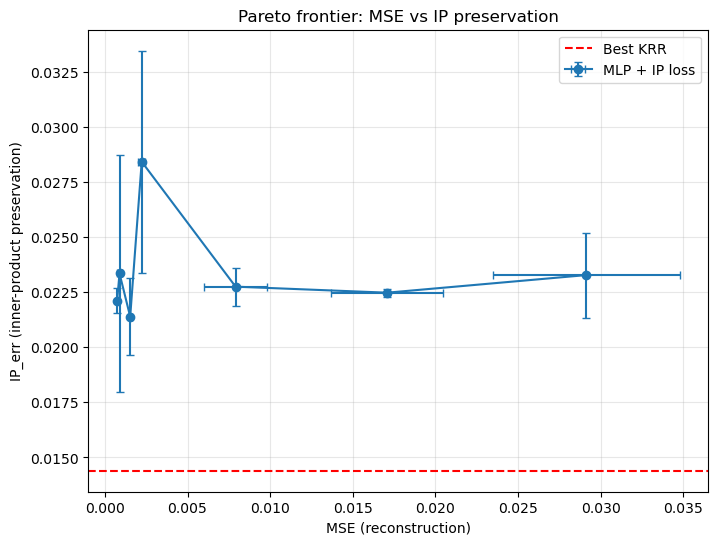

In [54]:
# Cell 48 — Pareto frontier with error bars (final version)
# (uses Cell 46 code)

import matplotlib.pyplot as plt

w_ips = [0.0, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0]
means_mse, means_ip, std_mse, std_ip = [], [], [], []

for w_ip in w_ips:
    mses, ips = [], []
    for seed in (42, 123, 7):
        torch.manual_seed(seed); np.random.seed(seed)
        n_val = 500
        z_tr, psi_tr_ = z_train[:-n_val], psi_train4[:-n_val]
        z_va, psi_va_ = z_train[-n_val:], psi_train4[-n_val:]
        model, _ = train_model(
            TinyMLP4q(hidden=128), z_tr, psi_tr_, z_va, psi_va_,
            epochs=2000, lr=1e-3, w_mse=1.0, w_ip=w_ip, verbose=False,
        )
        r = evaluate(model, z_test, psi_test4)
        mses.append(r["mse"]); ips.append(r["ip_err"])
    means_mse.append(np.mean(mses)); std_mse.append(np.std(mses))
    means_ip.append(np.mean(ips));   std_ip.append(np.std(ips))

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(means_mse, means_ip, xerr=std_mse, yerr=std_ip,
            fmt='o-', capsize=3, label='MLP + IP loss')
# KRR as a horizontal line
ax.axhline(0.0144, color='red', linestyle='--', label='Best KRR')
ax.set_xlabel('MSE (reconstruction)')
ax.set_ylabel('IP_err (inner-product preservation)')
ax.set_title('Pareto frontier: MSE vs IP preservation')
ax.grid(True, alpha=0.3)
ax.legend()
plt.savefig('paper/figures/pareto_frontier.png', dpi=200, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'paper/figures/pareto_frontier.png'

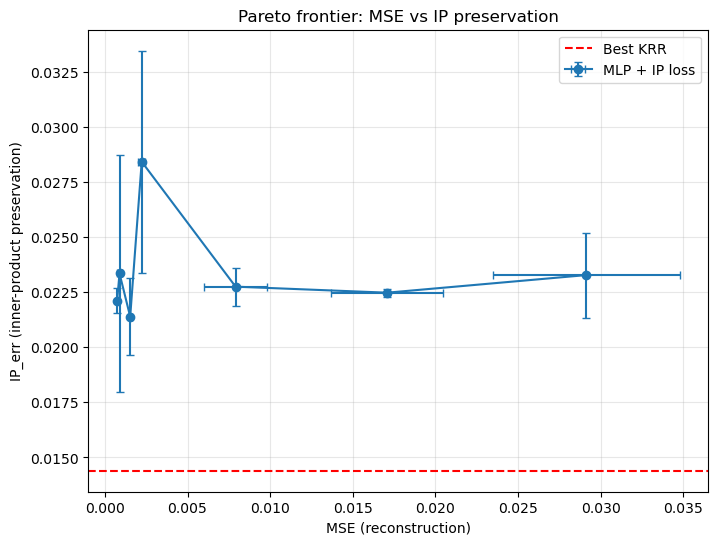

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(means_mse, means_ip, xerr=std_mse, yerr=std_ip,
            fmt='o-', capsize=3, label='MLP + IP loss')
# KRR as a horizontal line
ax.axhline(0.0144, color='red', linestyle='--', label='Best KRR')
ax.set_xlabel('MSE (reconstruction)')
ax.set_ylabel('IP_err (inner-product preservation)')
ax.set_title('Pareto frontier: MSE vs IP preservation')
ax.grid(True, alpha=0.3)
ax.legend()
plt.savefig('paper/figures/pareto_frontier.png', dpi=200, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'paper/figures/rank_ablation.png'

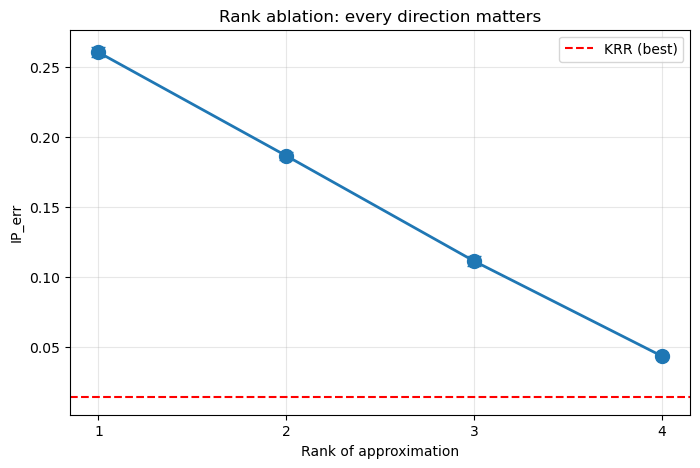

In [56]:
# Cell 49 — Rank ablation plot

seeds = [42, 123, 7]
ranks = [1, 2, 3, 4]
# Use the numbers from Cell 42:
# full IP_errs: [0.0446, 0.0430, 0.0434]
# rank 1: [0.2635, 0.2627, 0.2554]
# rank 2: [0.1905, 0.1864, 0.1831]
# rank 3: [0.1139, 0.1067, 0.1139]
data = np.array([
    [0.2635, 0.1905, 0.1139, 0.0446],   # seed 42
    [0.2627, 0.1864, 0.1067, 0.0430],   # seed 123
    [0.2554, 0.1831, 0.1139, 0.0434],   # seed 7
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(ranks, data.mean(axis=0), yerr=data.std(axis=0),
            fmt='o-', capsize=5, linewidth=2, markersize=10)
ax.axhline(0.0144, color='red', linestyle='--', label='KRR (best)')
ax.set_xlabel('Rank of approximation')
ax.set_ylabel('IP_err')
ax.set_title('Rank ablation: every direction matters')
ax.set_xticks(ranks)
ax.grid(True, alpha=0.3)
ax.legend()
plt.savefig('paper/figures/rank_ablation.png', dpi=200, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'paper/figures/fig3_method_comparison.png'

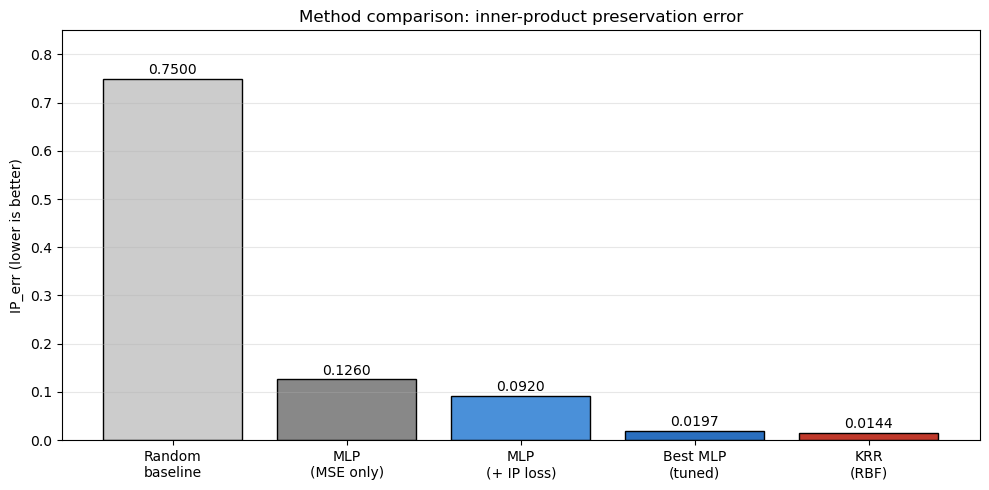

In [57]:
# Cell 50 — KRR vs MLP comparison bar chart

import matplotlib.pyplot as plt
import numpy as np

methods = ["Random\nbaseline", "MLP\n(MSE only)", "MLP\n(+ IP loss)",
           "Best MLP\n(tuned)", "KRR\n(RBF)"]
ip_errs = [0.75, 0.126, 0.092, 0.0197, 0.0144]
colors = ["#cccccc", "#888888", "#4a90d9", "#2a6fbf", "#c0392b"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, ip_errs, color=colors, edgecolor='black')

# Annotate
for bar, val in zip(bars, ip_errs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f"{val:.4f}", ha='center', fontsize=10)

ax.set_ylabel("IP_err (lower is better)")
ax.set_title("Method comparison: inner-product preservation error")
ax.set_ylim(0, 0.85)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("paper/figures/fig3_method_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'paper/figures/fig4_primary_direction.png'

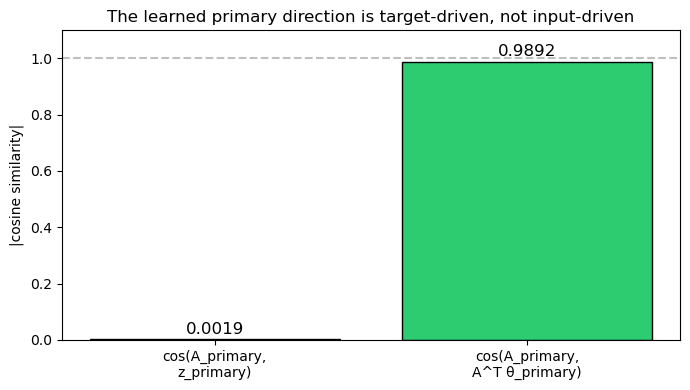

In [58]:
# Cell 51 — Primary direction comparison

import matplotlib.pyplot as plt
import numpy as np

labels = ["cos(A_primary,\nz_primary)", "cos(A_primary,\nA^T θ_primary)"]
values = [0.0019, 0.9892]
colors = ["#cccccc", "#2ecc71"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colors, edgecolor='black')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f"{val:.4f}", ha='center', fontsize=12)

ax.set_ylabel("|cosine similarity|")
ax.set_title("The learned primary direction is target-driven, not input-driven")
ax.set_ylim(0, 1.1)
ax.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("paper/figures/fig4_primary_direction.png", dpi=200, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'paper/figures/fig5_subspace_heatmap.png'

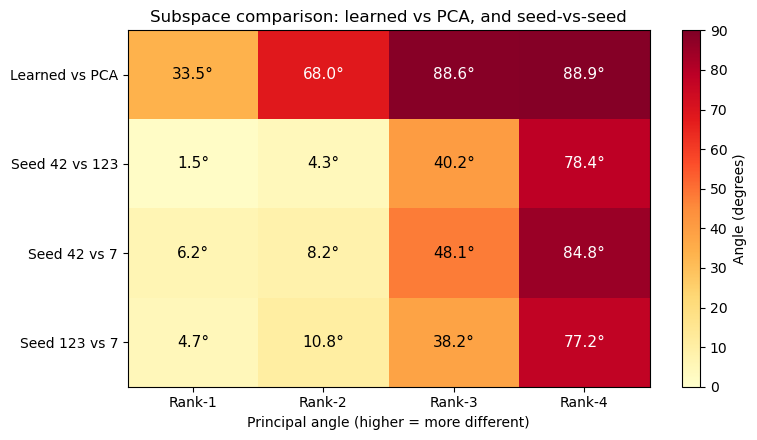

In [59]:
# Cell 52 — Subspace comparison heatmap

import matplotlib.pyplot as plt
import numpy as np

# Data from Cell 38 and 40
# Principal angles (degrees)
learned_vs_pca = [33.48, 67.98, 88.58, 88.91]   # from Cell 38
seed42_vs_123  = [1.52, 4.35, 40.20, 78.36]     # from Cell 40
seed42_vs_7    = [6.25, 8.20, 48.15, 84.85]
seed123_vs_7   = [4.66, 10.78, 38.17, 77.20]

# Matrix: rows = comparison, cols = principal angle rank
matrix = np.array([
    learned_vs_pca,
    seed42_vs_123,
    seed42_vs_7,
    seed123_vs_7,
])

row_labels = [
    "Learned vs PCA",
    "Seed 42 vs 123",
    "Seed 42 vs 7",
    "Seed 123 vs 7",
]
col_labels = ["Rank-1", "Rank-2", "Rank-3", "Rank-4"]

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(matrix, cmap="YlOrRd", aspect='auto', vmin=0, vmax=90)

# Annotate
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        text = ax.text(j, i, f"{matrix[i, j]:.1f}°",
                       ha="center", va="center",
                       color="black" if matrix[i, j] < 60 else "white",
                       fontsize=11)

ax.set_xticks(range(len(col_labels)))
ax.set_yticks(range(len(row_labels)))
ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)
ax.set_xlabel("Principal angle (higher = more different)")
ax.set_title("Subspace comparison: learned vs PCA, and seed-vs-seed")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Angle (degrees)")

plt.tight_layout()
plt.savefig("paper/figures/fig5_subspace_heatmap.png", dpi=200, bbox_inches='tight')
plt.show()